<a href="https://colab.research.google.com/github/GusthavoSoares/tech_challenge_data_analytics/blob/main/Analise_Receita_Olist_TechChallenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Importante bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
#Importando dataset
customers = pd.read_csv('olist_customers_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('olist_order_reviews_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
geolocation = pd.read_csv('olist_geolocation_dataset.csv')

#Pergunta de Negócio: Qual categoria de produto teve maior valor de receita acumulado no período. Das top 5 categorias, qual teve maior crescimento de receita no período

#Preparando o dataframe para análise  
Para a resposta da pergunta e uma análise mais aprofundada, utilizaremos algumas colunas de cada tabela para gerar um dataframe novo em cima do qual a análise será feita.

In [3]:
#Verificação das tabelas disponíveis no dataset
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


De 'customers', serão utilizadas as colunas 'costumer_id', 'customer_city' e 'customer_state'

In [5]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [6]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


De 'orders' serão utilizadas as colunas 'order_id, 'customer_id', 'order_status' e 'order_approved_at'. Na análise serão consideradas apenas pedidos com o status 'entregue' e a data de compra como referência será a que o pedido foi aprovado.

In [7]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [8]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


De 'order_items' serão utilizadas as colunas 'order_id', 'product_id', 'price' e 'freight_value'. A receita dos pedidos será considerada a soma entre o preço do produto e o frete do pedido.

In [9]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [10]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


De 'products' serão utilizadas as colunas 'product_id' e 'procut_category_name'. Dessa forma iremos definir qual a categoria com maior receita e crescimento no período

In [11]:
#Criação das tabelas principais para análise, considerando colunas selecionadas anteriormente e filtros

#1. Merge orders e customers utilizando 'customer_id'
df_analise = pd.merge(
    orders[['order_id', 'customer_id', 'order_status', 'order_approved_at']],
    customers[['customer_id', 'customer_city', 'customer_state']],
    on='customer_id',
    how='inner'
)

#2. Merge df_analise e order_items utilizando 'order_id'
df_analise = pd.merge(
    df_analise,
    order_items[['order_id', 'product_id', 'price', 'freight_value']],
    on='order_id',
    how='inner'
)

#3. Merge df_analise e products utilizando 'product_id'
df_analise = pd.merge(
    df_analise,
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

#Aplicando o filtro apenas para analisarmos pedidos entregues
df_analise = df_analise[df_analise['order_status'] == 'delivered']

#Conversão de 'order_approved_at' para data
df_analise['order_approved_at'] = pd.to_datetime(df_analise['order_approved_at'])

#Definindo as colunas princpiais para tratamento de valores nulos
colunas_principais = ['customer_id', 'customer_city', 'customer_state', 'order_id', 'order_approved_at', 'product_id', 'product_category_name', 'price', 'freight_value']
df_analise.dropna(subset = colunas_principais, inplace = True)
df_analise.reset_index(drop = True, inplace = True)

#Definição final de df_analise
df_analise = df_analise[colunas_principais]

#Definição de df_produtos com a coluna 'receita' sendo a soma do preço e frete
df_produtos = df_analise[['customer_id', 'customer_city', 'customer_state', 'product_id', 'product_category_name', 'price', 'freight_value', 'order_approved_at']]
df_produtos['receita'] = df_produtos['price'] + df_produtos['freight_value']

In [12]:
#Verificação de df_analise
df_analise.head()

,customer_id,customer_city,customer_state,order_id,order_approved_at,product_id,product_category_name,price,freight_value
0,9ef432eb6251297304e76186b10a928d,sao paulo,SP,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 11:07:15,87285b34884572647811a353c7ac498a,utilidades_domesticas,29.99,8.72
1,b0830fb4747a6c6d20dea0b8c802d7ef,barreiras,BA,53cdb2fc8bc7dce0b6741e2150273451,2018-07-26 03:24:27,595fac2a385ac33a80bd5114aec74eb8,perfumaria,118.70,22.76
2,41ce2a54c0b03bf3443c3d931a367089,vianopolis,GO,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:55:23,aa4383b373c6aca5d8797843e5594415,automotivo,159.90,19.22
3,f88197465ea7920adcdbec7375364d82,sao goncalo do amarante,RN,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:45:59,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop,45.00,27.20
4,8ab97904e6daea8866dbdbc4fb7aad2c,santo andre,SP,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 22:20:29,65266b2da20d04dbe00c5c2d3bb7859e,papelaria,19.90,8.72


In [13]:
df_analise.isna().sum()

,0
customer_id,0
customer_city,0
customer_state,0
order_id,0
order_approved_at,0
product_id,0
product_category_name,0
price,0
freight_value,0


In [14]:
df_analise.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108646 entries, 0 to 108645
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   customer_id            108646 non-null  object        
 1   customer_city          108646 non-null  object        
 2   customer_state         108646 non-null  object        
 3   order_id               108646 non-null  object        
 4   order_approved_at      108646 non-null  datetime64[ns]
 5   product_id             108646 non-null  object        
 6   product_category_name  108646 non-null  object        
 7   price                  108646 non-null  float64       
 8   freight_value          108646 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(6)
memory usage: 7.5+ MB


In [15]:
#Verificação de df_produtos
df_produtos.head()

,customer_id,customer_city,customer_state,product_id,product_category_name,price,freight_value,order_approved_at,receita
0,9ef432eb6251297304e76186b10a928d,sao paulo,SP,87285b34884572647811a353c7ac498a,utilidades_domesticas,29.99,8.72,2017-10-02 11:07:15,38.71
1,b0830fb4747a6c6d20dea0b8c802d7ef,barreiras,BA,595fac2a385ac33a80bd5114aec74eb8,perfumaria,118.70,22.76,2018-07-26 03:24:27,141.46
2,41ce2a54c0b03bf3443c3d931a367089,vianopolis,GO,aa4383b373c6aca5d8797843e5594415,automotivo,159.90,19.22,2018-08-08 08:55:23,179.12
3,f88197465ea7920adcdbec7375364d82,sao goncalo do amarante,RN,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop,45.00,27.20,2017-11-18 19:45:59,72.20
4,8ab97904e6daea8866dbdbc4fb7aad2c,santo andre,SP,65266b2da20d04dbe00c5c2d3bb7859e,papelaria,19.90,8.72,2018-02-13 22:20:29,28.62


In [16]:
df_produtos.isna().sum()

,0
customer_id,0
customer_city,0
customer_state,0
product_id,0
product_category_name,0
price,0
freight_value,0
order_approved_at,0
receita,0


In [17]:
df_produtos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108646 entries, 0 to 108645
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   customer_id            108646 non-null  object        
 1   customer_city          108646 non-null  object        
 2   customer_state         108646 non-null  object        
 3   product_id             108646 non-null  object        
 4   product_category_name  108646 non-null  object        
 5   price                  108646 non-null  float64       
 6   freight_value          108646 non-null  float64       
 7   order_approved_at      108646 non-null  datetime64[ns]
 8   receita                108646 non-null  float64       
dtypes: datetime64[ns](1), float64(3), object(5)
memory usage: 7.5+ MB


#Início da Análise, definição das 10 categorias com maior receita no período

In [18]:
top5_categorias = df_produtos.groupby('product_category_name')['receita'].sum().sort_values(ascending=False).head(5).index.tolist()
top5_categorias

['beleza_saude',
 'relogios_presentes',
 'cama_mesa_banho',
 'esporte_lazer',
 'informatica_acessorios']

In [19]:
#Criação de tabela com as top 5 categorias e agrupando as receita das categorias por mês
df_top5_produtos = df_produtos[df_produtos['product_category_name'].isin(top5_categorias)].copy()
df_top5_produtos['mes'] = df_top5_produtos['order_approved_at'].dt.to_period('M').dt.start_time
receita_mensal_por_categoria = df_top5_produtos.groupby(['product_category_name', 'mes'])['receita'].sum().reset_index()
receita_mensal_por_categoria.head()

,product_category_name,mes,receita
0,beleza_saude,2016-09-01,143.46
1,beleza_saude,2016-10-01,4186.29
2,beleza_saude,2017-01-01,11883.11
3,beleza_saude,2017-02-01,26961.82
4,beleza_saude,2017-03-01,29509.34


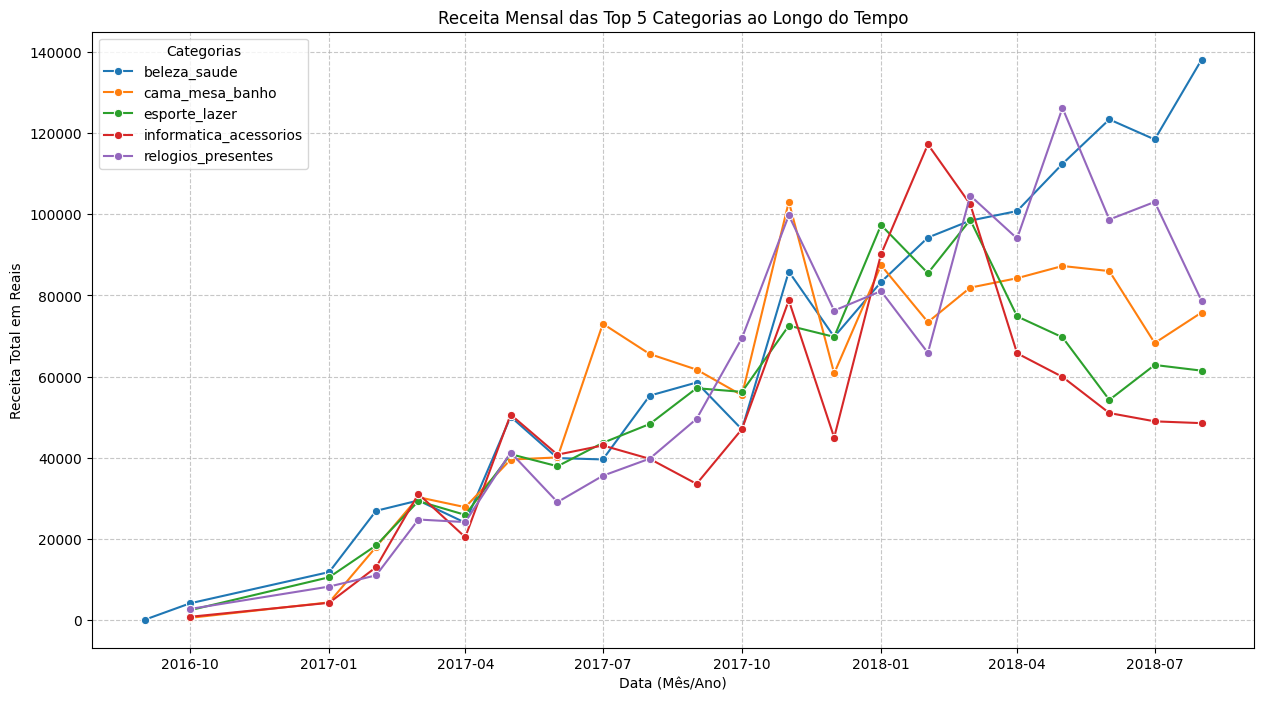

In [25]:
#Visualização da Receita Mensal das Top 10 Categorias ao longo do tempo
plt.figure(figsize=(15,8))
sns.lineplot(data=receita_mensal_por_categoria, x='mes', y='receita', hue='product_category_name', marker='o')
plt.title('Receita Mensal das Top 5 Categorias ao Longo do Tempo')
plt.xlabel('Data (Mês/Ano)')
plt.ylabel('Receita Total em Reais')
plt.xticks(rotation=0)
plt.grid(True, linestyle = '--', alpha = 0.7)
plt.legend(title='Categorias')
plt.show()

Como apenas a categoria 'beleza_saude' tem dados de antes de outbro de 2016 e não temos dados dos meses de novembro e dezembro de 2016, adotaremos um novo filtro considerando a partir de janeiro de 2017

In [21]:
#Filtrando os dados a partir de janeiro de 2017 para garantir dados consistentes para todas as categorias
receita_mensal_por_categoria_filtrada = receita_mensal_por_categoria[receita_mensal_por_categoria['mes'] >= '2017-01-01'].copy()


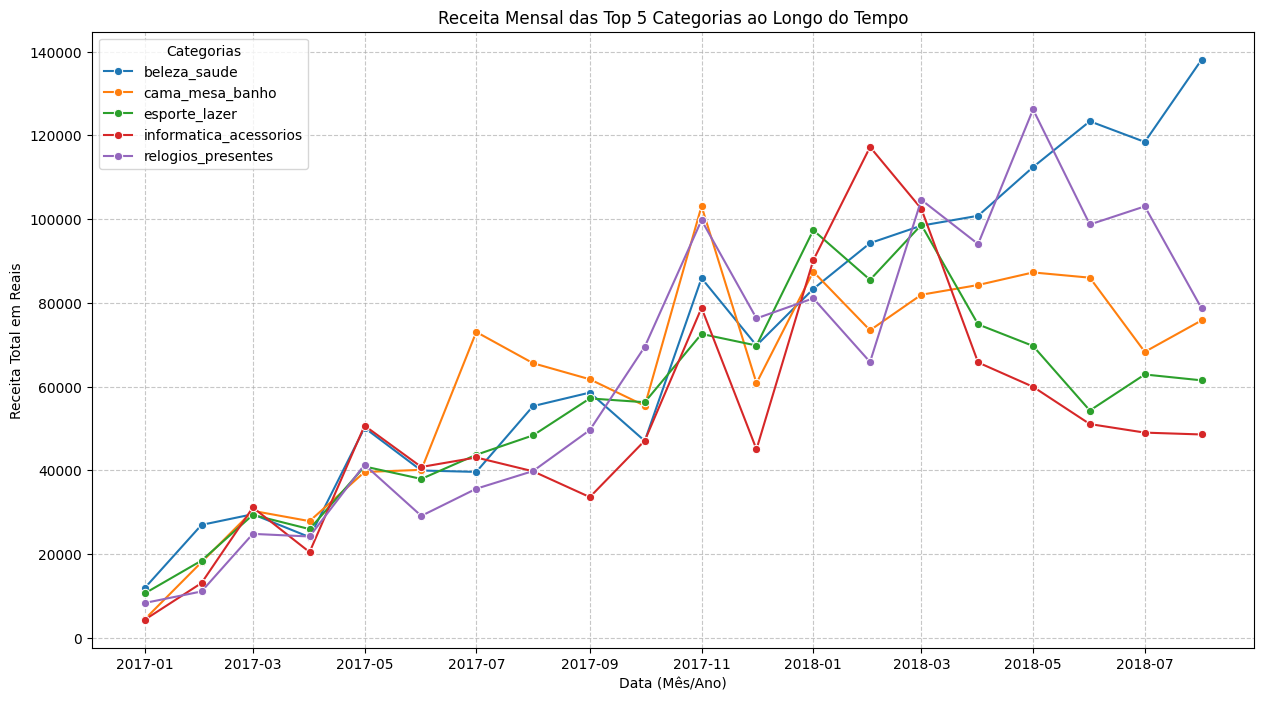

In [26]:
#Visualização da Receita Mensal das Top 10 Categorias ao longo do tempo (Jan/17 - Ago/18)
plt.figure(figsize=(15,8))
sns.lineplot(data=receita_mensal_por_categoria_filtrada, x='mes', y='receita', hue='product_category_name', marker='o')
plt.title('Receita Mensal das Top 5 Categorias ao Longo do Tempo')
plt.xlabel('Data (Mês/Ano)')
plt.ylabel('Receita Total em Reais')
plt.xticks(rotation=0)
plt.grid(True, linestyle = '--', alpha = 0.7)
plt.legend(title='Categorias')
plt.show()

No gráfico acima é possível ver o corportamento mês a mês das receitas das categorias, a partir da análise abaixo, validaremos qual categoria teve maior crescimento de receita dentro do período (Jan/17 - Ago/18)

In [23]:
#Cálculo da receita para o primeiro e o último mês de cada categoria
receita_por_categoria = receita_mensal_por_categoria_filtrada.groupby('product_category_name').agg(
    receita_primeiro_mes  = ('receita', 'first'),
    receita_ultimo_mes = ('receita', 'last')
).reset_index()

#Função para calcular a porcentagem de crescimento
def percentual_crescimento_receita_mensal(linha):
  if linha['receita_primeiro_mes'] != 0:
    return ((linha['receita_ultimo_mes'] - linha['receita_primeiro_mes']) / linha['receita_primeiro_mes']) * 100
  else:
    return 0

#Aplicando a função para calcular a porcentagem de crescimento
receita_por_categoria['percentual_de_crescimento'] = receita_por_categoria.apply(percentual_crescimento_receita_mensal, axis=1)

receita_por_categoria.sort_values(by='percentual_de_crescimento', ascending = False)

,product_category_name,receita_primeiro_mes,receita_ultimo_mes,percentual_de_crescimento
1,cama_mesa_banho,4417.21,75800.75,1616.032292
0,beleza_saude,11883.11,138058.44,1061.803939
3,informatica_acessorios,4313.95,48556.15,1025.561261
4,relogios_presentes,8310.83,78680.09,846.717596
2,esporte_lazer,10604.85,61484.96,479.781515


Com a tabela acima, temos que a categoria que teve um maior crescimento de receita no período foi 'cama_mesa_banho' seguida por 'beleza_saude' e 'informatica_acessorios'. Mesmo com beleza saúde tendo a maior receita acumulada no período, conforme visto na tabela abaixo:

In [24]:
#Verificação da receita total por categoria
receita_mensal_por_categoria_filtrada.groupby('product_category_name')['receita'].sum().sort_values(ascending=False).reset_index()

,product_category_name,receita
0,beleza_saude,1407759.78
1,relogios_presentes,1261539.41
2,cama_mesa_banho,1224445.49
3,esporte_lazer,1115671.69
4,informatica_acessorios,1031861.93


Outro ponto importante é também destacar o crescimento de receita de todas as categorias do top5 no mês de novembro, representado pela blackfriday